In [0]:
# ==========================================
# Import Required Libraries
# ==========================================

from pyspark.sql import functions as F

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

In [0]:
# ==========================================
# Load Cleaned Parquet Files
# ==========================================

meta_df = spark.read.parquet(
    "/Volumes/project/default/data/clean/meta_clean.parquet"
)

reviews_df = spark.read.parquet(
    "/Volumes/project/default/data/clean/reviews_clean.parquet"
)

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [0]:
# ==========================================
# Join Metadata and Reviews
# ==========================================

combined_df = (
    reviews_df.join(
        meta_df,
        on="parent_asin",
        how="inner"
    )
)

print(f"Combined Dataset Records : {combined_df.count():,}")
print(f"Total Columns            : {len(combined_df.columns)}")

Combined Dataset Records : 2,105,948
Total Columns            : 27


In [0]:
display(combined_df.limit(5))

parent_asin,asin,helpful_vote,images,rating,text,timestamp,title,user_id,verified_purchase,review_length,review_date,review_year,review_month,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,bought_together
B06Y3JRMMG,B06Y3JRMMG,1,"List(List(IMAGE, https://images-na.ssl-images-amazon.com/images/I/61uFabzIA7L.jpg, https://images-na.ssl-images-amazon.com/images/I/61uFabzIA7L._SL800_.jpg, https://images-na.ssl-images-amazon.com/images/I/61uFabzIA7L._SL256_.jpg), List(IMAGE, https://images-na.ssl-images-amazon.com/images/I/712lR2JKpVL.jpg, https://images-na.ssl-images-amazon.com/images/I/712lR2JKpVL._SL800_.jpg, https://images-na.ssl-images-amazon.com/images/I/712lR2JKpVL._SL256_.jpg), List(IMAGE, https://images-na.ssl-images-amazon.com/images/I/713eL1Fu1gL.jpg, https://images-na.ssl-images-amazon.com/images/I/713eL1Fu1gL._SL800_.jpg, https://images-na.ssl-images-amazon.com/images/I/713eL1Fu1gL._SL256_.jpg), List(IMAGE, https://images-na.ssl-images-amazon.com/images/I/717rIaKw4YL.jpg, https://images-na.ssl-images-amazon.com/images/I/717rIaKw4YL._SL800_.jpg, https://images-na.ssl-images-amazon.com/images/I/717rIaKw4YL._SL256_.jpg))",2.0,"Received it about 5 days after I ordered even though I have prime. I had to miss two days of work to get it. Then they didn't actually drop it off while I was at home waiting the whole time, they kept it pushing and never rang my bell or anything, I ended up having to go to actually UPS location to pick it up wth a damn stranger as I don't drive and I knew if I didn't pick it up myself I would never get it.Then when I finally got it, the drum was looking lop sided, like something in it might have been broken but I wasn't sure. And there was like some little denting in the front at the bottom but nothing too crazy. Anyway I said let me take a chance and see if it will do anything. I hooked it up and everything, the displays and what not turned on fine, the adapter couldn't fit my sink though and I didn't want to lug it to the kitchen just to rest it so I manually filled it on the lowest water level setting. Unfortunately it never actually did anything, it never spun. Nothing. It just made this steady low humming noise and the countdown was working on the screen but the machine itself was not doing ANYTHING AT ALL. Unfortunately I don't have video, that's how disappointed I was I forgot to take video, I was there with it for hours hoping it would start to spin but it never did.Anyway I wrapped it up hapheartledly, so crushed I was really looking forward to it, I think if it actually worked I wouldave been really happy as it was actually pretty light to move around if you just use a little effort and the drum was huge, I fit a lot of stuff in it when I was trying to see just how much would fit. The drain hose is also not too bad and it hooks into the side of the machine. The pipe hose was actually pretty sturdy too but it didn't actually fit my sink like I said.Sadly though....it was not meant for me. :( super disappointed.",1506042501723,If it worked I might have been happy.,AFUX5LK62NLYOCK5JP7HT7QMINZQ,true,1888,2017-09-22T01:08:21.000Z,2017,9,Appliances,"Ivation Portable Automatic 2 in 1 Washer/Spinner with Built-in Drain Pump Washes Up To 17 lbs of Laundry – Self-Cleaning Feature & Removable Filter for Ultimate Convenience, Easy To Install & Use",3.4,41,"List(To Install Follow Simple Diagrams In User Guide To Secure Sole Plate, Water Source & Drainage Hose & You Can Begin Washing, This Portable Washer Has Same Cleaning Capacity As Any Regular Sized Washing Machine; Handles Full Loads Of Cloths & Linen, Compact Size With Mere 20” Width & Depth & Height Under 3 Feet, This 50 lb. Washer Is Great For Any Size Apartment; Makes Moving A Breeze, Offers 5 Water Levels & 5 Different Settings: Soak, Wash, Rinse, Spin, Air Dry; Cleans Perfectly Any Type Or Amount Of Laundry, It’s Easy To Keep Your Ivation Washer Functioning At Optimum Levels, 

In [0]:
# ==========================================
# Price vs Rating
# ==========================================

price_rating = (
    combined_df
    .filter(
        (F.col("price").isNotNull()) &
        (F.col("average_rating").isNotNull()) &
        (F.col("price") > 0)
    )
    .select(
        "price",
        "average_rating"
    )
)

# Remove extreme prices (99th percentile)
price_limit = price_rating.approxQuantile(
    "price",
    [0.99],
    0.01
)[0]

price_rating = (
    price_rating
    .filter(F.col("price") <= price_limit)
)

price_rating_pd = price_rating.toPandas()

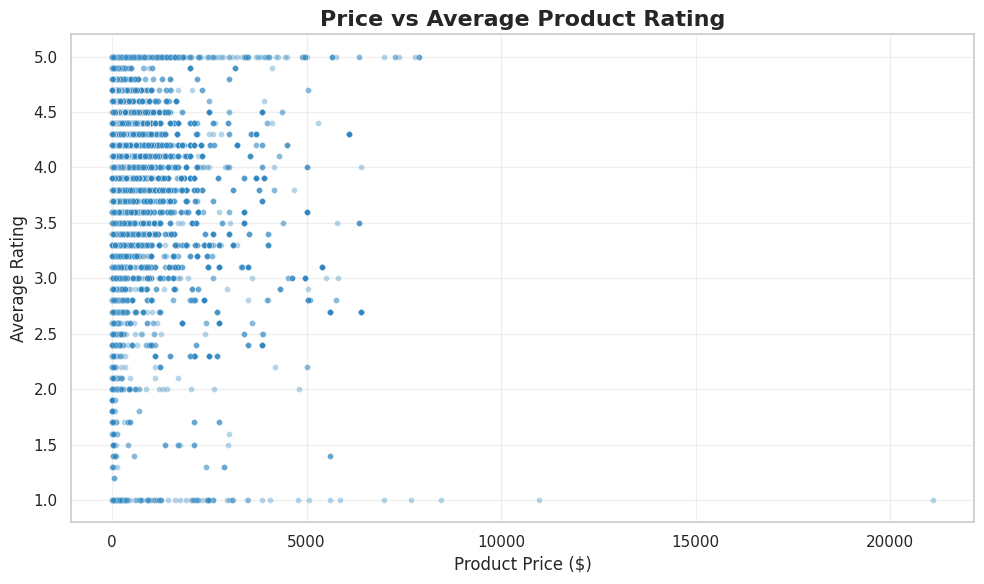

In [0]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=price_rating_pd,
    x="price",
    y="average_rating",
    alpha=0.35,
    s=18,
    color="#2E86C1"
)

plt.title(
    "Price vs Average Product Rating",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Product Price ($)")
plt.ylabel("Average Rating")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [0]:
# ==========================================
# Correlation Analysis
# ==========================================

corr_df = (
    combined_df
    .select(
        "price",
        "average_rating",
        "rating_number",
        "rating",
        "helpful_vote",
        "review_length"
    )
    .dropna()
)

corr_pd = corr_df.toPandas()

corr_pd.head()

,price,average_rating,rating_number,rating,helpful_vote,review_length
0,61.40,4.8,47,5.0,1,256
1,8.00,4.8,11229,5.0,0,32
2,7.99,4.6,3426,5.0,6,293
3,16.99,4.4,722,5.0,0,46
4,18.99,4.1,51,3.0,1,116


In [0]:
corr_matrix = corr_pd.corr(numeric_only=True)

corr_matrix

,price,average_rating,rating_number,rating,helpful_vote,review_length
price,1.000000,-0.210556,-0.045241,-0.062906,0.044623,0.140110
average_rating,-0.210556,1.000000,0.188229,0.259488,-0.029173,-0.114132
rating_number,-0.045241,0.188229,1.000000,0.007521,-0.003403,-0.041192
rating,-0.062906,0.259488,0.007521,1.000000,-0.023774,-0.138664
helpful_vote,0.044623,-0.029173,-0.003403,-0.023774,1.000000,0.177929
review_length,0.140110,-0.114132,-0.041192,-0.138664,0.177929,1.000000


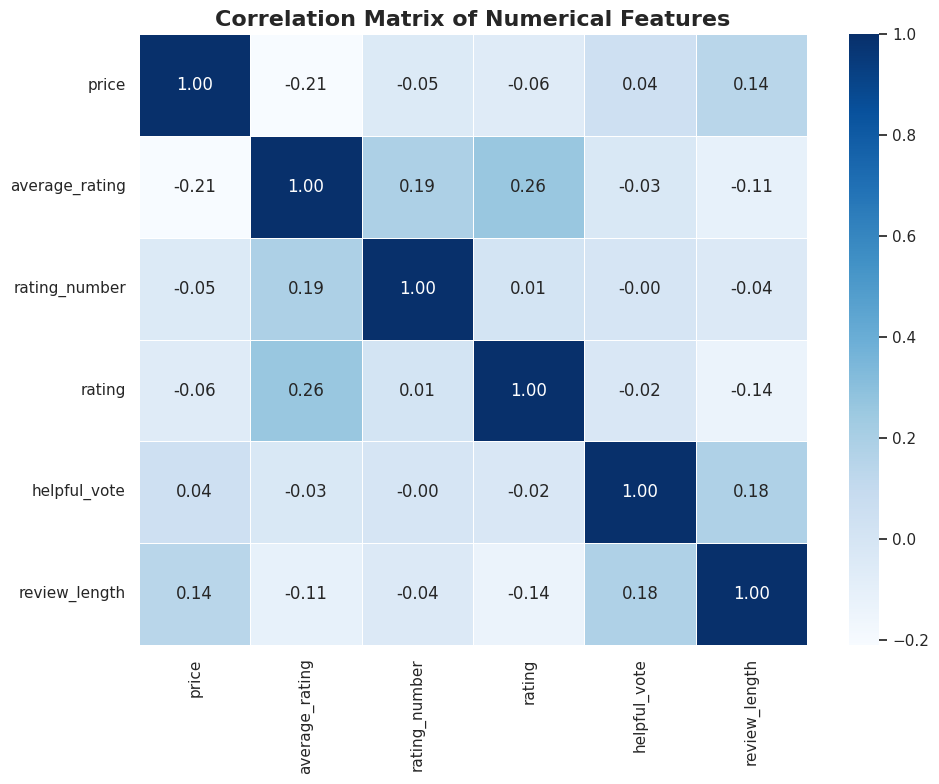

In [0]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()

plt.show()

In [0]:
help_length = (
    combined_df
    .select(
        "helpful_vote",
        "review_length"
    )
    .dropna()
)

help_limit = help_length.approxQuantile(
    "helpful_vote",
    [0.99],
    0.01
)[0]

help_length = (
    help_length
    .filter(
        F.col("helpful_vote") <= help_limit
    )
)

help_length_pd = help_length.toPandas()

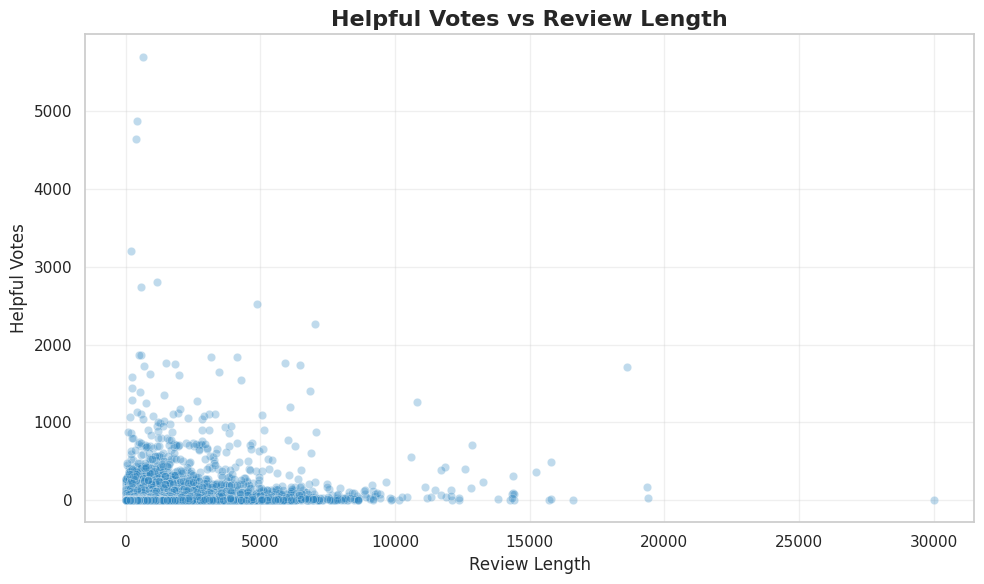

In [0]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=help_length_pd,
    x="review_length",
    y="helpful_vote",
    alpha=0.30,
    color="#2E86C1"
)

plt.title(
    "Helpful Votes vs Review Length",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Review Length")
plt.ylabel("Helpful Votes")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [0]:
rating_length = (
    combined_df
    .select(
        "rating",
        "review_length"
    )
    .dropna()
)

rating_length_pd = rating_length.toPandas()

/home/spark-68099dce-d77a-4df6-870b-dd/.ipykernel/335/command-8381539768323351-1467203667:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


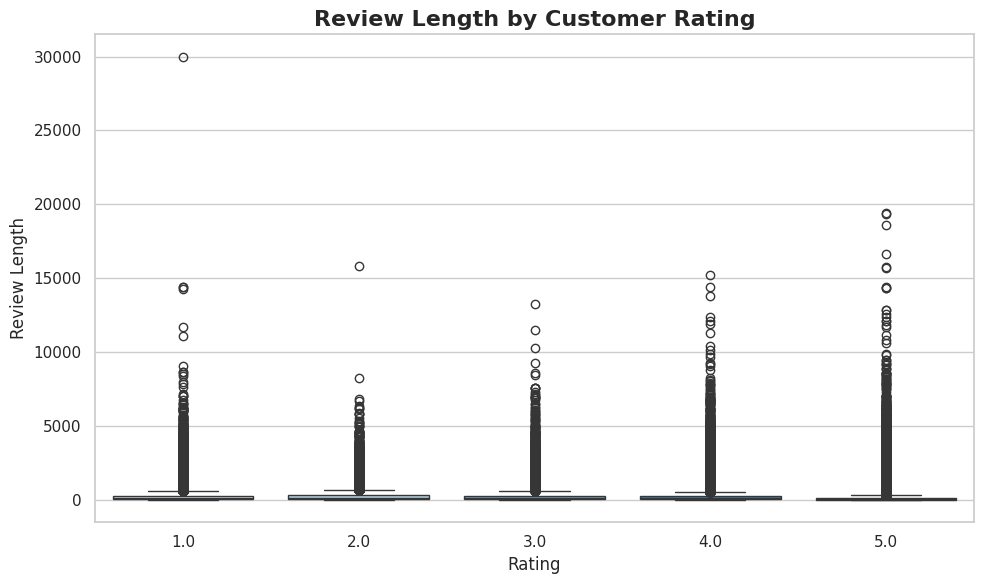

In [0]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=rating_length_pd,
    x="rating",
    y="review_length",
    palette="Blues"
)

plt.title(
    "Review Length by Customer Rating",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Rating")
plt.ylabel("Review Length")

plt.tight_layout()

plt.show()

In [0]:
# ==========================================
# Verified Purchase vs Rating
# ==========================================

verified_rating = (
    combined_df
    .select(
        "verified_purchase",
        "rating"
    )
    .dropna()
)

verified_rating_pd = verified_rating.toPandas()

verified_rating_pd["verified_purchase"] = verified_rating_pd[
    "verified_purchase"
].replace({
    True: "Verified Purchase",
    False: "Non-Verified Purchase"
})

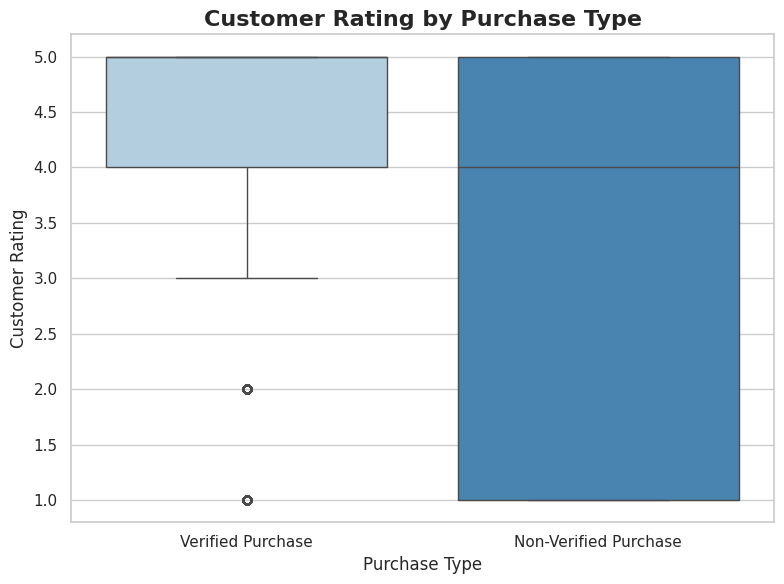

In [0]:
# ==========================================
# Verified Purchase vs Rating
# ==========================================

plt.figure(figsize=(8,6))

sns.boxplot(
    data=verified_rating_pd,
    x="verified_purchase",
    y="rating",
    hue="verified_purchase",
    palette="Blues",
    legend=False
)

plt.title(
    "Customer Rating by Purchase Type",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Purchase Type")
plt.ylabel("Customer Rating")

plt.tight_layout()

plt.show()

In [0]:
# ==========================================
# Rating Count vs Average Rating
# ==========================================

popularity = (
    combined_df
    .select(
        "rating_number",
        "average_rating"
    )
    .dropna()
)

rating_limit = popularity.approxQuantile(
    "rating_number",
    [0.99],
    0.01
)[0]

popularity = (
    popularity
    .filter(
        F.col("rating_number") <= rating_limit
    )
)

popularity_pd = popularity.toPandas()

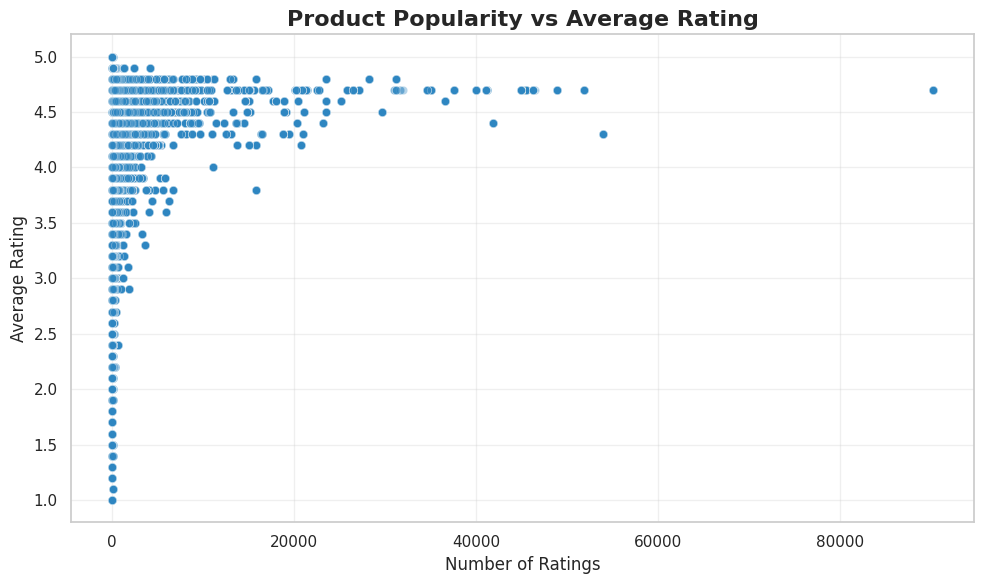

In [0]:
# ==========================================
# Rating Count vs Average Rating
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=popularity_pd,
    x="rating_number",
    y="average_rating",
    alpha=0.35,
    color="#2E86C1"
)

plt.title(
    "Product Popularity vs Average Rating",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

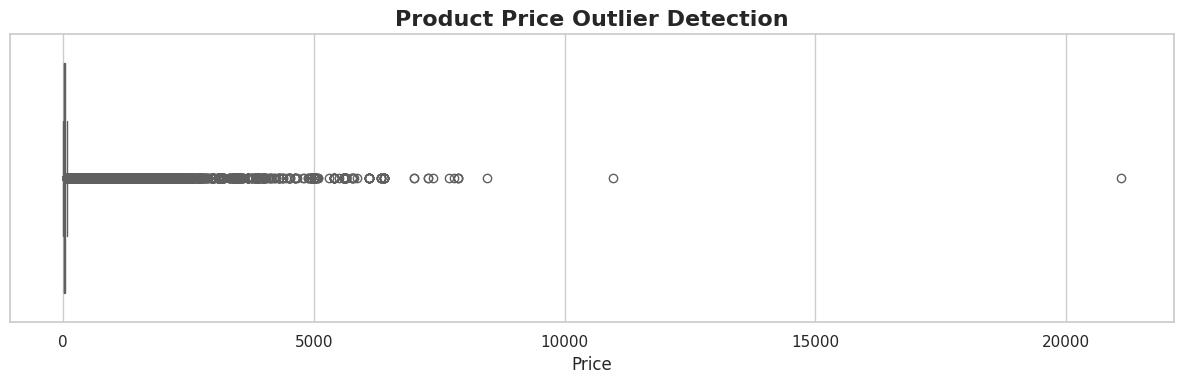

In [0]:
# ==========================================
# Outlier Detection
# ==========================================

plt.figure(figsize=(12,4))

sns.boxplot(
    x=combined_df.select("price").dropna().toPandas()["price"],
    color="#5DADE2"
)

plt.title(
    "Product Price Outlier Detection",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Price")

plt.tight_layout()

plt.show()

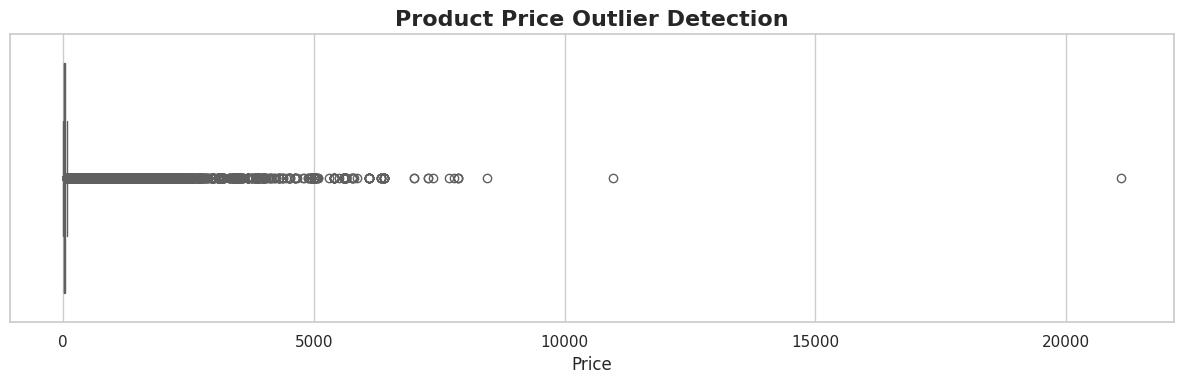

In [0]:
# ==========================================
# Outlier Detection
# ==========================================

plt.figure(figsize=(12,4))

sns.boxplot(
    x=combined_df.select("price").dropna().toPandas()["price"],
    color="#5DADE2"
)

plt.title(
    "Product Price Outlier Detection",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Price")

plt.tight_layout()

plt.show()

In [0]:
# ==========================================
# Relationship Analysis Summary
# ==========================================

summary = pd.DataFrame({
    "Analysis": [
        "Price vs Rating",
        "Review Length vs Helpful Votes",
        "Verified Purchase vs Rating",
        "Popularity vs Rating",
        "Outlier Detection"
    ],
    "Key Observation": [
        "Weak Relationship",
        "Positive Relationship",
        "Verified reviews more consistent",
        "Weak Relationship",
        "Premium price outliers detected"
    ]
})

summary

,Analysis,Key Observation
0,Price vs Rating,Weak Relationship
1,Review Length vs Helpful Votes,Positive Relationship
2,Verified Purchase vs Rating,Verified reviews more consistent
3,Popularity vs Rating,Weak Relationship
4,Outlier Detection,Premium price outliers detected


# Key Business Insights

- Product price has limited influence on customer satisfaction.
- Longer reviews generally receive higher community engagement.
- Verified purchases improve review credibility.
- Product popularity is independent of product quality.
- Outliers should be considered during predictive modeling.